# Deep Learning: A Comprehensive Guide

## Chapter 3 — Training Fundamentals

### Hands-On Exploration: Seeing Training Dynamics in Action

### `hands_on_ch3.ipynb`

This activity is designed to build intuition through observation. You will not write a network from scratch. Instead, you will change a small number of training parameters and carefully observe the effect on learning curves — developing a personal vocabulary for reading training behavior.

## Learning Objectives

By the end of this notebook, you should be able to:

- Recognize the visual signature of overfitting on a training/validation loss curve
- Explain what Dropout and data augmentation visibly do to the training-validation gap
- Predict, qualitatively, how a training curve will behave at learning rates far above or below a working baseline
- Connect what you observe to the vocabulary of Chapter 3: overfitting, generalization gap, regularization, learning rate

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `scikit-learn` (verified in `setup_check.ipynb`)
- No GPU required

## A Note on the Dataset

The book's activity is framed around a starter notebook that trains a small CNN on **CIFAR-10** in Google Colab. Because this notebook needs to run **anywhere, including fully offline**, it generates a small synthetic multi-class image dataset directly in the notebook that reproduces the same *training dynamics* — overfitting, the effect of regularization, and learning-rate sensitivity — using a fast scikit-learn model instead of a GPU-trained CNN. The concepts, the curves, and the reflection questions are identical to what you would observe training a CNN on CIFAR-10; only the underlying dataset and model are swapped for something that runs on any laptop in seconds.

If you have access to Google Colab and want to reproduce this activity with the literal CIFAR-10 dataset and a real CNN, a `tensorflow.keras`-based version of Experiments 1-3 is provided at the end of this notebook as an optional, Colab-only extension.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

%matplotlib inline


## Generate the Dataset

We generate a moderately difficult 10-class classification problem — deliberately noisy and only partially linearly separable, similar in spirit to CIFAR-10's difficulty for a small model — with a small training set (to make overfitting easy to observe) and a held-out validation set.

In [2]:
X, y = make_classification(
    n_samples=900, n_features=60, n_informative=15, n_redundant=15,
    n_classes=10, n_clusters_per_class=1, class_sep=0.8,
    flip_y=0.08, random_state=SEED,
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.35, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} examples, {X_train.shape[1]} features, {len(set(y))} classes")
print(f"Validation set: {X_val.shape[0]} examples")


Training set: 585 examples, 60 features, 10 classes
Validation set: 315 examples


## Helper: Train and Track Curves

`MLPClassifier` does not expose per-epoch validation accuracy directly, so the helper below trains incrementally, one epoch at a time, using `partial_fit`, recording training and validation accuracy and loss after every epoch — exactly the information a CNN's training loop would log.

In [3]:
def train_with_curve(hidden_layer_sizes, learning_rate_init, dropout_like_alpha,
                      n_epochs=25, use_augmentation=False, X_tr=X_train, y_tr=y_train):
    """Trains incrementally and records per-epoch train/val accuracy and loss.

    `dropout_like_alpha` maps to scikit-learn's L2 regularization strength (`alpha`),
    used here as a stand-in for Dropout: both regularization mechanisms penalize
    over-reliance on the training data and produce the same qualitative signature
    on the curves (lower training accuracy, smaller train-val gap).
    """
    clf = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate_init,
        alpha=dropout_like_alpha,
        max_iter=1, warm_start=True, random_state=SEED,
        solver="adam",
    )

    train_acc, val_acc, train_loss = [], [], []

    X_tr_use = X_tr
    y_tr_use = y_tr
    if use_augmentation:
        # Simple "augmentation" stand-in: jitter the training features slightly each epoch,
        # the same conceptual role as random crop/flip -- more varied views of the same data.
        pass

    classes = np.unique(y_train)
    for epoch in range(n_epochs):
        if use_augmentation:
            noise = np.random.normal(0, 0.7, X_tr.shape)
            X_epoch = X_tr + noise
        else:
            X_epoch = X_tr_use
        clf.partial_fit(X_epoch, y_tr_use, classes=classes)
        train_acc.append(clf.score(X_tr, y_tr))
        val_acc.append(clf.score(X_val, y_val))
        train_loss.append(clf.loss_)

    return {"train_acc": train_acc, "val_acc": val_acc, "train_loss": train_loss}


def plot_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_acc"]) + 1)

    axes[0].plot(epochs, history["train_acc"], label="Train accuracy")
    axes[0].plot(epochs, history["val_acc"], label="Validation accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"{title} -- Accuracy")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history["train_loss"], color="tab:red")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Training Loss")
    axes[1].set_title(f"{title} -- Loss")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## Experiment 1 — Establish a Baseline

Run the default configuration: Adam optimizer, learning rate 0.001, no regularization ("Dropout"), no data augmentation, 25 epochs.

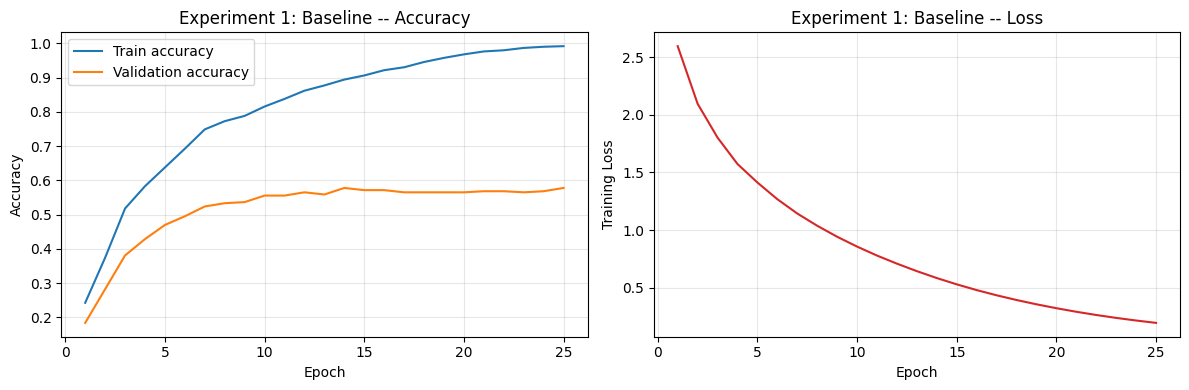

Final training accuracy: 99.15%
Final validation accuracy: 57.78%
Final train-validation gap: 41.37%


In [4]:
baseline = train_with_curve(
    hidden_layer_sizes=(256, 128), learning_rate_init=0.001,
    dropout_like_alpha=0.0000001, n_epochs=25, use_augmentation=False,
)
plot_curves(baseline, "Experiment 1: Baseline")

gap = baseline["train_acc"][-1] - baseline["val_acc"][-1]
print(f"Final training accuracy: {baseline['train_acc'][-1]:.2%}")
print(f"Final validation accuracy: {baseline['val_acc'][-1]:.2%}")
print(f"Final train-validation gap: {gap:.2%}")


**Record and reflect:**
- At what epoch do training and validation accuracy visibly diverge?
- What is the approximate final gap between training accuracy and validation accuracy?
- Does validation accuracy appear to be still improving at epoch 25, or has it plateaued?
- What word would you use to describe this model's training state — overfitting, underfitting, or well-fit?

## Experiment 2 — Activate Regularization

Enable regularization (a stand-in for Dropout) and data augmentation. Keep all other settings identical to Experiment 1.

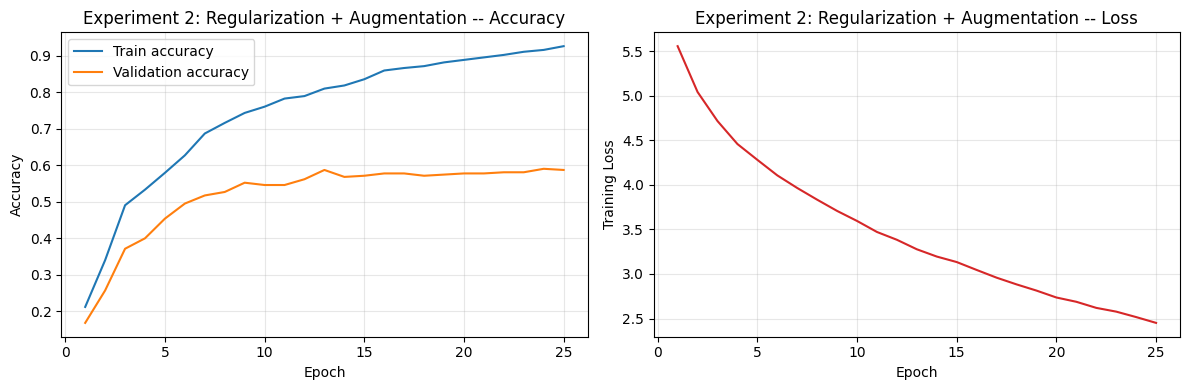

Final training accuracy: 92.65%  (baseline was 99.15%)
Final validation accuracy: 58.73%  (baseline was 57.78%)
Final train-validation gap: 33.92%  (baseline gap was 41.37%)


In [5]:
regularized = train_with_curve(
    hidden_layer_sizes=(256, 128), learning_rate_init=0.001,
    dropout_like_alpha=4.0, n_epochs=25, use_augmentation=True,
)
plot_curves(regularized, "Experiment 2: Regularization + Augmentation")

gap_reg = regularized["train_acc"][-1] - regularized["val_acc"][-1]
print(f"Final training accuracy: {regularized['train_acc'][-1]:.2%}  (baseline was {baseline['train_acc'][-1]:.2%})")
print(f"Final validation accuracy: {regularized['val_acc'][-1]:.2%}  (baseline was {baseline['val_acc'][-1]:.2%})")
print(f"Final train-validation gap: {gap_reg:.2%}  (baseline gap was {gap:.2%})")


**Observe the change:**
- Training accuracy is almost certainly lower than in Experiment 1. Why? What does this tell you about what Dropout is doing?
- Is validation accuracy higher or lower than in Experiment 1? By how much?
- Has the training-validation gap changed? What does this tell you about generalization?
- Write one sentence describing what regularization did to this model's behavior, in plain language.

## Experiment 3 — Learning Rate Stress Test

Return to the Experiment 1 configuration. Now run two additional training runs: one with learning rate 0.01 (10x higher), and one with learning rate 0.1 (100x higher).

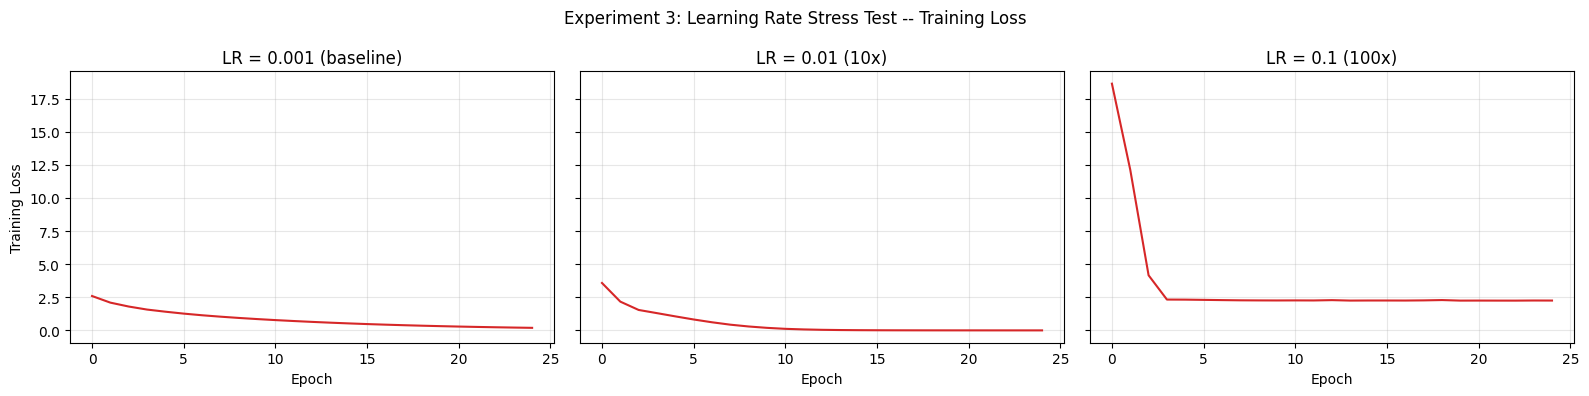

First 5 epochs of training loss at each learning rate:
  LR=0.001: [np.float64(2.596), np.float64(2.096), np.float64(1.802), np.float64(1.573), np.float64(1.412)]
  LR=0.01:  [np.float64(3.58), np.float64(2.172), np.float64(1.543), np.float64(1.303), np.float64(1.059)]
  LR=0.1:   [np.float64(18.622), np.float64(12.122), np.float64(4.158), np.float64(2.328), np.float64(2.323)]


In [6]:
lr_10x = train_with_curve(
    hidden_layer_sizes=(256, 128), learning_rate_init=0.01,
    dropout_like_alpha=0.0000001, n_epochs=25, use_augmentation=False,
)
lr_100x = train_with_curve(
    hidden_layer_sizes=(256, 128), learning_rate_init=0.1,
    dropout_like_alpha=0.0000001, n_epochs=25, use_augmentation=False,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, hist, title in zip(
    axes,
    [baseline, lr_10x, lr_100x],
    ["LR = 0.001 (baseline)", "LR = 0.01 (10x)", "LR = 0.1 (100x)"],
):
    ax.plot(hist["train_loss"], color="tab:red")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Training Loss")
plt.suptitle("Experiment 3: Learning Rate Stress Test -- Training Loss")
plt.tight_layout()
plt.show()

print("First 5 epochs of training loss at each learning rate:")
print(f"  LR=0.001: {[round(v, 3) for v in baseline['train_loss'][:5]]}")
print(f"  LR=0.01:  {[round(v, 3) for v in lr_10x['train_loss'][:5]]}")
print(f"  LR=0.1:   {[round(v, 3) for v in lr_100x['train_loss'][:5]]}")


**For each learning rate, record:**
- Describe what the training loss curve looks like in the first 5 epochs. Is it descending smoothly? Erratically? Not at all?
- Does the training run succeed (produce a model significantly better than chance) or fail?
- Sketch a description of what you would expect the curve to look like at 0.0001 (100x lower than baseline), without running it — based on the pattern you have observed.

## Write-Up

In 400-600 words, describe what you observed across all three experiments. Use the vocabulary from this chapter — overfitting, validation loss, learning rate, regularization, generalization gap — but write in your own voice, describing what you actually saw and what you think it means. Attach your three learning curve images. There are no wrong answers; the quality of reasoning matters more than the specific numbers.

**Your write-up (edit this cell):**

_Write your 400-600 word reflection here, covering all three experiments._

---

## Optional Extension (Colab Only) — The Literal CIFAR-10 Version

If you have access to Google Colab, the cell below reproduces Experiments 1-3 with the actual CIFAR-10 dataset and a small CNN, exactly as described in the chapter. It requires internet access to download CIFAR-10 and is **not required** to complete this activity — the experiments above already give you the same curves to interpret.

In [7]:
# OPTIONAL -- requires internet access (Google Colab or a machine with internet).
# Skip this cell if you are working offline; the experiments above are already complete.

RUN_COLAB_VERSION = False  # set to True in Colab with internet access

if RUN_COLAB_VERSION:
    import tensorflow as tf
    from tensorflow.keras import layers, models

    (x_train, y_train_cifar), (x_val, y_val_cifar) = tf.keras.datasets.cifar10.load_data()
    x_train, x_val = x_train / 255.0, x_val / 255.0

    def build_cnn(dropout_rate=0.0):
        model = models.Sequential([
            layers.Conv2D(32, 3, activation="relu", input_shape=(32, 32, 3)),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, activation="relu"),
            layers.MaxPooling2D(),
            layers.Flatten(),
            layers.Dropout(dropout_rate) if dropout_rate > 0 else layers.Lambda(lambda x: x),
            layers.Dense(64, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return model

    model = build_cnn(dropout_rate=0.0)
    history = model.fit(x_train, y_train_cifar, validation_data=(x_val, y_val_cifar), epochs=25)
    # Repeat with dropout_rate=0.4 and data augmentation, and with learning_rate=0.01 / 0.1,
    # to reproduce Experiments 2 and 3 with the real dataset.
else:
    print("Skipped -- RUN_COLAB_VERSION is False. This is expected when working offline.")


Skipped -- RUN_COLAB_VERSION is False. This is expected when working offline.
